# Medication Adherence & Digital Reminder Impact

**Project 7 · Digital health analytics**

Chronic disease outcomes depend on patients taking maintenance medication consistently. Here we use pharmacy refill data from **20,000 patients** with hypertension, type 2 diabetes, hyperlipidemia, COPD or heart failure to answer four questions:

1. **How adherent is the population?** We calculate PDC and MPR, the two standard claims-based adherence metrics.
2. **Do patients enrolled in the app's reminder programme refill more reliably?** We compare users and non-users with statistical tests, then adjust for the fact that users self-select.
3. **Which patients are at risk?** We segment the population by adherence risk so that outreach can be prioritised.
4. **Can we predict non-adherence at enrolment?** We build a simple, interpretable model from information available on day one.

> All data are synthetic, produced by `generate_data.py` (seeded and reproducible). Opt-in to the app is deliberately confounded, so the analysis has to separate the *app effect* from the kind of patient who downloads the app.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.max_columns", 30)

DATA = Path("data"); IMG = Path("images"); OUT = Path("outputs")
IMG.mkdir(exist_ok=True); OUT.mkdir(exist_ok=True)
SEED = 7

### Visual theme
Every chart and the slide deck share one palette. It was checked with a colour-vision-deficiency validator, and every chart also carries direct labels, so the reader never has to rely on colour alone.

| Role | Colour |
|---|---|
| Reminder users | teal `#009490` |
| Non-users | orange `#E26A2C` |
| Third series / model | violet `#5B4BC4` |
| Ink / muted ink / grid | `#1F2A30` / `#5E6B70` / `#E6E9EA` |

In [2]:
TEAL, ORANGE, VIOLET = "#009490", "#E26A2C", "#5B4BC4"
INK, MUTED, GRID, SURFACE = "#1F2A30", "#5E6B70", "#E6E9EA", "#FFFFFF"
RISK = ["#F6C9A8", "#EE9A68", "#E26A2C", "#A8441A"]   # ordinal orange ramp: low -> very high
GROUP_COLORS = {"App reminder users": TEAL, "Non-users": ORANGE}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 26,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.frameon": False, "legend.fontsize": 10, "figure.dpi": 110, "savefig.dpi": 160,
    "savefig.bbox": "tight",
})

def subtitle(ax, text):
    ax.text(0, 1.015, text, transform=ax.transAxes, color=MUTED, fontsize=10, va="bottom")

def save(fig, name):
    fig.savefig(IMG / f"{name}.png")
    plt.show()

pct = mtick.PercentFormatter(1.0, decimals=0)

## 1. Load the data

In [3]:
patients = pd.read_csv(DATA / "patients.csv.gz")
enrol = pd.read_csv(DATA / "app_enrollment.csv.gz", parse_dates=["enrollment_date"])
rx = pd.read_csv(DATA / "prescriptions.csv.gz", parse_dates=["start_date"])
fills = pd.read_csv(DATA / "refills.csv.gz", parse_dates=["fill_date"])
logs = pd.read_csv(DATA / "reminder_logs.csv.gz", parse_dates=["sent_at"])

for name, df in [("patients", patients), ("app_enrollment", enrol), ("prescriptions", rx),
                 ("refills", fills), ("reminder_logs", logs)]:
    print(f"{name:15s} {len(df):>8,d} rows x {df.shape[1]:>2d} cols   nulls: {int(df.isna().sum().sum()):,d}")

patients          20,000 rows x 17 cols   nulls: 0
app_enrollment     7,707 rows x  7 cols   nulls: 0
prescriptions     33,655 rows x  8 cols   nulls: 0
refills          213,422 rows x  7 cols   nulls: 0
reminder_logs    100,796 rows x  8 cols   nulls: 22,580


In [4]:
patients.head()

,patient_id,age,sex,region,urbanicity,insurance_type,hypertension,type2_diabetes,hyperlipidemia,copd,heart_failure,n_chronic_conditions,depression_dx,prior_year_hospitalizations,smartphone_owner,digital_literacy_score,monthly_copay_usd
0,P00001,61,Male,Central,Urban,Commercial,1,0,0,0,0,1,0,1,1,6.900,21.610
1,P00002,65,Female,South,Urban,Medicare,1,0,0,0,0,1,0,0,1,5.600,13.230
2,P00003,57,Female,South,Urban,Medicaid,1,1,0,0,0,2,0,1,1,6.800,2.450
3,P00004,49,Female,Central,Urban,Commercial,1,1,1,0,0,3,0,1,1,6.800,29.310
4,P00005,55,Female,West,Suburban,Medicare,0,1,0,0,0,1,0,0,1,7.000,6.080


In [5]:
# Quality checks: unique keys, referential integrity, date ranges
assert patients.patient_id.is_unique and rx.rx_id.is_unique and fills.fill_id.is_unique
assert fills.rx_id.isin(rx.rx_id).all() and logs.rx_id.isin(rx.rx_id).all()
assert enrol.patient_id.isin(patients.patient_id).all()
print("Fill dates:", fills.fill_date.min().date(), "to", fills.fill_date.max().date())
print("Reminder timestamps:", logs.sent_at.min(), "to", logs.sent_at.max())
print("Only response_minutes has nulls (reminders that were ignored):",
      logs.response_minutes.isna().sum() == (logs.action == "Ignored").sum())

Fill dates: 2025-01-01 to 2025-12-31
Reminder timestamps: 2025-01-28 08:00:00 to 2026-01-03 19:28:00
Only response_minutes has nulls (reminders that were ignored): True


## 2. Adherence metrics: PDC and MPR

We define both metrics over the **2025 measurement year**, starting at each prescription's index (first) fill and running to 31 December.

* **PDC (proportion of days covered)** is the number of days the patient had medication on hand, divided by the days in the period. When a patient refills early, the new supply is **shifted to start the day after the previous supply runs out**, so a day is never counted twice. PDC is therefore capped at 100% by construction. It is the metric used in Pharmacy Quality Alliance (PQA) and CMS Star Ratings measures, and **PDC ≥ 80%** is the standard adherence threshold.
* **MPR (medication possession ratio)** is the total days' supply dispensed divided by the days in the period. It does not correct for overlapping fills, so it can exceed 100% and tends to *overstate* adherence. We report both the raw MPR and MPR capped at 1.0.

Following PQA convention, a prescription counts towards the measure only once the patient has filled it **at least twice**. At patient level we average PDC across the patient's eligible prescriptions and call the patient *adherent* when that average is 80% or higher. We also report the stricter "adherent to every medication" rate.

In [6]:
PERIOD_END = pd.Timestamp("2025-12-31")

def adherence_by_rx(fills, period_end=PERIOD_END):
    '''PDC (with carry-over shifting) and MPR for every prescription.'''
    f = fills.sort_values(["rx_id", "fill_date"])
    rx_ids = f.rx_id.to_numpy()
    day = (f.fill_date - pd.Timestamp("2025-01-01")).dt.days.to_numpy()
    sup = f.days_supply.to_numpy()
    end_day = (period_end - pd.Timestamp("2025-01-01")).days + 1   # exclusive
    out = {}
    cur_rx, start, covered_to, covered, supply, n = None, 0, 0, 0, 0, 0
    def flush():
        period = end_day - start
        out[cur_rx] = (n, start, period, covered / period, supply / period)
    for r, d, s in zip(rx_ids, day, sup):
        if r != cur_rx:
            if cur_rx is not None:
                flush()
            cur_rx, start, covered_to, covered, supply, n = r, d, d, 0, 0, 0
        seg_start = max(d, covered_to)                 # shift early refills forward
        seg_end = seg_start + s
        covered += max(0, min(seg_end, end_day) - min(seg_start, end_day))
        covered_to = seg_end
        supply += s
        n += 1
    flush()
    res = pd.DataFrame.from_dict(out, orient="index",
                                 columns=["n_fills", "index_day", "period_days", "pdc", "mpr_raw"])
    res["mpr_capped"] = res.mpr_raw.clip(upper=1)
    return res.rename_axis("rx_id").reset_index()

rx_adh = adherence_by_rx(fills).merge(rx, on="rx_id")
rx_adh["eligible"] = rx_adh.n_fills >= 2
print(f"Prescriptions: {len(rx_adh):,d}; eligible (>=2 fills): {rx_adh.eligible.mean():.1%}")
rx_adh.loc[rx_adh.eligible, ["pdc", "mpr_raw", "mpr_capped"]].describe().T

Prescriptions: 33,655; eligible (>=2 fills): 97.7%


,count,mean,std,min,25%,50%,75%,max
pdc,"32,880.000",0.816,0.181,0.155,0.718,0.865,0.968,1.000
mpr_raw,"32,880.000",0.890,0.230,0.164,0.750,0.922,1.056,1.304
mpr_capped,"32,880.000",0.849,0.187,0.164,0.750,0.922,1.000,1.000


In [7]:
elig = rx_adh[rx_adh.eligible].copy()
elig["adherent"] = elig.pdc >= 0.8

pt = (elig.groupby("patient_id")
          .agg(pdc=("pdc", "mean"), mpr_raw=("mpr_raw", "mean"), mpr_capped=("mpr_capped", "mean"),
               min_pdc=("pdc", "min"), n_rx=("rx_id", "size"),
               share_90day=("standard_days_supply", lambda s: (s == 90).mean()))
          .reset_index())
pt["adherent"] = (pt.pdc >= 0.8).astype(int)
pt["adherent_all_meds"] = (pt.min_pdc >= 0.8).astype(int)
pt["non_adherent"] = 1 - pt.adherent

df = patients.merge(pt, on="patient_id", how="inner").merge(enrol, on="patient_id", how="left")
df["app_user"] = df.enrollment_date.notna().astype(int)
df["group"] = np.where(df.app_user == 1, "App reminder users", "Non-users")
df["daily_dose_reminders_on"] = df.daily_dose_reminders_on.fillna(0).astype(int)
df["caregiver_alerts_on"] = df.caregiver_alerts_on.fillna(0).astype(int)

print(f"Patients with >=1 eligible prescription: {len(df):,d} of {len(patients):,d}")
print(f"Mean PDC {df.pdc.mean():.1%} | mean MPR (raw) {df.mpr_raw.mean():.1%} | mean MPR (capped) {df.mpr_capped.mean():.1%}")
print(f"Adherent (mean PDC >= 80%): {df.adherent.mean():.1%} | adherent on every medication: {df.adherent_all_meds.mean():.1%}")
print(f"Patients flagged adherent by capped MPR but not by PDC: {((df.mpr_capped >= .8) & (df.pdc < .8)).mean():.1%}")

Patients with >=1 eligible prescription: 19,781 of 20,000
Mean PDC 82.2% | mean MPR (raw) 89.6% | mean MPR (capped) 85.4%
Adherent (mean PDC >= 80%): 62.8% | adherent on every medication: 54.5%
Patients flagged adherent by capped MPR but not by PDC: 6.5%


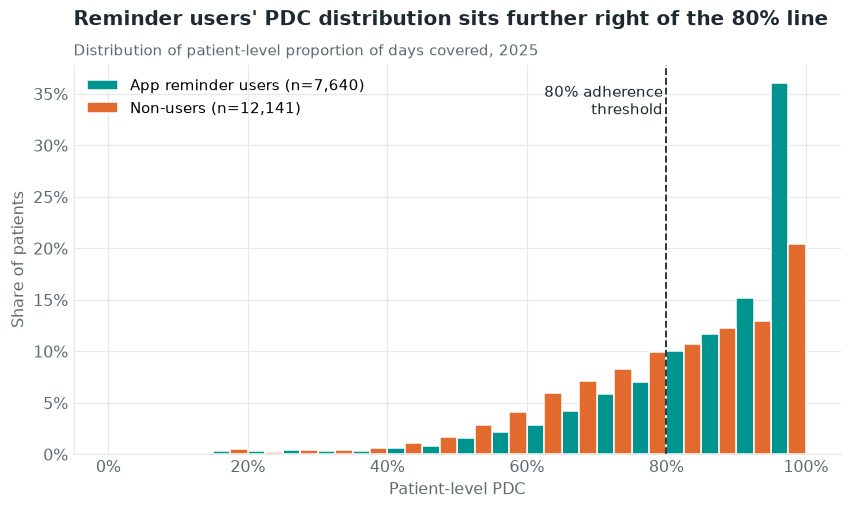

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.6))
bins = np.linspace(0, 1, 21); w = 0.05 / 2
for k, (g, c) in enumerate(GROUP_COLORS.items()):
    x = df.loc[df.group == g, "pdc"]
    h = np.histogram(x, bins=bins)[0] / len(x)
    ax.bar(bins[:-1] + w * k + w / 2, h, width=w, color=c, edgecolor=SURFACE, linewidth=1, label=f"{g} (n={len(x):,d})")
ax.axvline(0.8, color=INK, lw=1.2, ls="--")
ax.text(0.795, ax.get_ylim()[1] * 0.95, "80% adherence\nthreshold", ha="right", va="top", color=INK, fontsize=9.5)
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("Patient-level PDC"); ax.set_ylabel("Share of patients")
ax.set_title("Reminder users' PDC distribution sits further right of the 80% line")
subtitle(ax, "Distribution of patient-level proportion of days covered, 2025")
ax.legend(loc="upper left")
save(fig, "01_pdc_distribution")

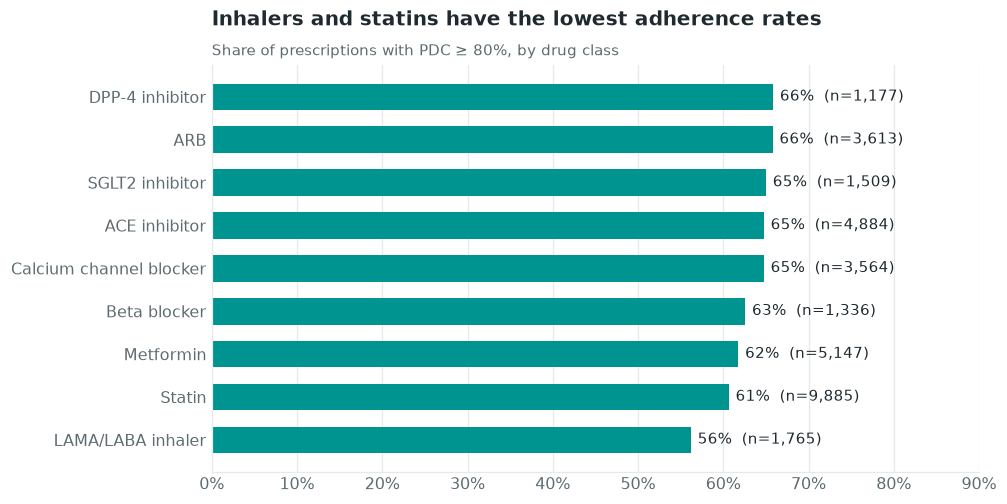

,pdc,mpr,adherent,n
drug_class,,,,
LAMA/LABA inhaler,0.788,0.861,0.562,1765
Statin,0.807,0.880,0.606,9885
Metformin,0.814,0.886,0.618,5147
Beta blocker,0.816,0.889,0.626,1336
Calcium channel blocker,0.828,0.902,0.648,3564
ACE inhibitor,0.825,0.900,0.648,4884
SGLT2 inhibitor,0.827,0.901,0.650,1509
ARB,0.828,0.903,0.658,3613
DPP-4 inhibitor,0.829,0.908,0.658,1177


In [9]:
by_drug = (elig.groupby("drug_class")
               .agg(pdc=("pdc", "mean"), mpr=("mpr_raw", "mean"), adherent=("adherent", "mean"), n=("rx_id", "size"))
               .sort_values("adherent"))
fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(by_drug))
ax.barh(y, by_drug.adherent, color=TEAL, height=0.62)
for yi, (a, n) in enumerate(zip(by_drug.adherent, by_drug.n)):
    ax.text(a + 0.008, yi, f"{a:.0%}  (n={n:,d})", va="center", color=INK, fontsize=9.5)
ax.set_yticks(y, by_drug.index); ax.set_xlim(0, 0.9)
ax.xaxis.set_major_formatter(pct); ax.grid(axis="y", visible=False)
ax.set_title("Inhalers and statins have the lowest adherence rates")
subtitle(ax, "Share of prescriptions with PDC ≥ 80%, by drug class")
save(fig, "02_adherence_by_drug_class")
by_drug

**Takeaways**
* The two metrics disagree. Raw MPR runs higher than PDC because it counts overlapping early refills twice. Some patients who look adherent on capped MPR fall below 80% on PDC, which is why PDC is the metric used for quality reporting.
* Statins and COPD maintenance inhalers show the familiar pattern: adherence is lowest for drugs whose benefit the patient doesn't feel, or whose side effects they do.

## 3. Reminder users vs non-users

### 3.1 Unadjusted comparison
We run several tests on the same comparison:
* **Welch's t-test** on mean PDC, which does not assume equal variances.
* **Mann-Whitney U**, because PDC is bounded and left-skewed. We report the rank-biserial correlation as its effect size.
* **Chi-square test** on the adherent (PDC ≥ 80%) rate, with the risk difference and its 95% confidence interval.
* **Cohen's d** as a standardised effect size.

In [10]:
u = df[df.app_user == 1]; n_ = df[df.app_user == 0]

t_stat, t_p = stats.ttest_ind(u.pdc, n_.pdc, equal_var=False)
mw_u, mw_p = stats.mannwhitneyu(u.pdc, n_.pdc, alternative="two-sided")
rank_biserial = 2 * mw_u / (len(u) * len(n_)) - 1
pooled_sd = np.sqrt(((len(u) - 1) * u.pdc.var() + (len(n_) - 1) * n_.pdc.var()) / (len(u) + len(n_) - 2))
cohens_d = (u.pdc.mean() - n_.pdc.mean()) / pooled_sd

ct = pd.crosstab(df.group, df.adherent)
chi2, chi_p, _, _ = stats.chi2_contingency(ct)
p1, p0 = u.adherent.mean(), n_.adherent.mean()
rd = p1 - p0
rd_se = np.sqrt(p1 * (1 - p1) / len(u) + p0 * (1 - p0) / len(n_))
rr = p1 / p0

summary = pd.DataFrame({
    "App reminder users": [len(u), u.pdc.mean(), u.pdc.median(), u.mpr_raw.mean(), p1, u.adherent_all_meds.mean()],
    "Non-users": [len(n_), n_.pdc.mean(), n_.pdc.median(), n_.mpr_raw.mean(), p0, n_.adherent_all_meds.mean()],
}, index=["Patients", "Mean PDC", "Median PDC", "Mean MPR (raw)", "Adherent (PDC ≥ 80%)", "Adherent on all meds"])
display(summary)

tests = pd.DataFrame([
    ["Welch t-test (mean PDC)", f"t = {t_stat:.2f}", f"{t_p:.2e}", f"Cohen's d = {cohens_d:.2f}"],
    ["Mann-Whitney U (PDC)", f"U = {mw_u:,.0f}", f"{mw_p:.2e}", f"rank-biserial r = {rank_biserial:.2f}"],
    ["Chi-square (adherent rate)", f"χ² = {chi2:.1f}", f"{chi_p:.2e}",
     f"RD = {rd:+.1%} (95% CI {rd - 1.96*rd_se:+.1%} to {rd + 1.96*rd_se:+.1%}); RR = {rr:.2f}"],
], columns=["Test", "Statistic", "p-value", "Effect size"])
tests

,App reminder users,Non-users
Patients,"7,640.000","12,141.000"
Mean PDC,0.857,0.799
Median PDC,0.905,0.830
Mean MPR (raw),0.935,0.872
Adherent (PDC ≥ 80%),0.729,0.564
Adherent on all meds,0.646,0.482


,Test,Statistic,p-value,Effect size
0,Welch t-test (mean PDC),t = 25.18,2.18e-137,Cohen's d = 0.36
1,Mann-Whitney U (PDC),"U = 57,374,585",4.95e-174,rank-biserial r = 0.24
2,Chi-square (adherent rate),χ² = 543.2,3.84e-120,RD = +16.5% (95% CI +15.1% to +17.8%); RR = 1.29


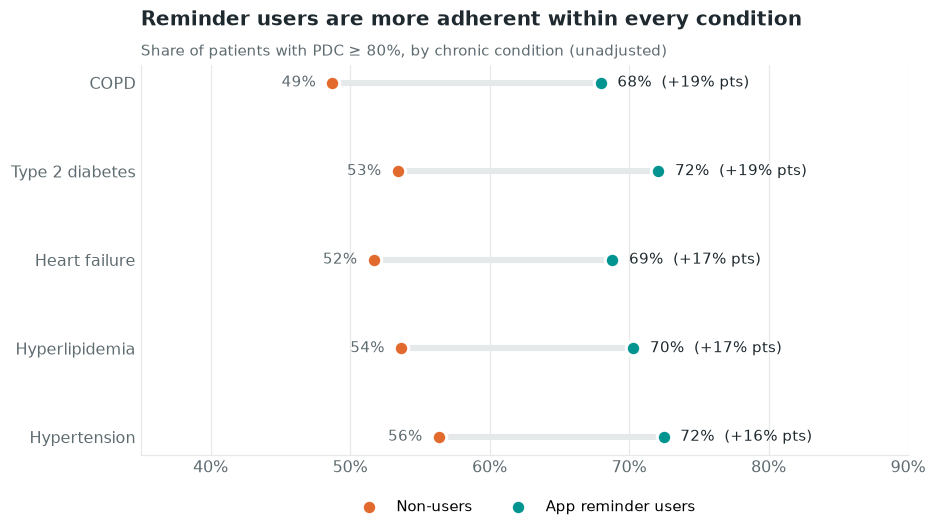

,condition,users,non_users,diff,p_value,n
0,Hypertension,0.725,0.564,0.161,0.000,12227
2,Hyperlipidemia,0.703,0.537,0.166,0.000,10084
4,Heart failure,0.688,0.517,0.171,0.000,1362
1,Type 2 diabetes,0.721,0.534,0.187,0.000,7954
3,COPD,0.680,0.487,0.192,0.000,1807


In [11]:
cond_cols = {"hypertension": "Hypertension", "type2_diabetes": "Type 2 diabetes", "hyperlipidemia": "Hyperlipidemia",
             "copd": "COPD", "heart_failure": "Heart failure"}
rows = []
for col, label in cond_cols.items():
    s = df[df[col] == 1]
    a, b = s[s.app_user == 1].adherent, s[s.app_user == 0].adherent
    _, p = stats.chi2_contingency(pd.crosstab(s.app_user, s.adherent))[:2]
    rows.append([label, a.mean(), b.mean(), a.mean() - b.mean(), p, len(s)])
by_cond = pd.DataFrame(rows, columns=["condition", "users", "non_users", "diff", "p_value", "n"]).sort_values("diff")

fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(by_cond))
ax.hlines(y, by_cond.non_users, by_cond.users, color=GRID, lw=4, zorder=1)
ax.scatter(by_cond.non_users, y, s=90, color=ORANGE, edgecolor=SURFACE, linewidth=2, zorder=3, label="Non-users")
ax.scatter(by_cond.users, y, s=90, color=TEAL, edgecolor=SURFACE, linewidth=2, zorder=3, label="App reminder users")
for yi, r in zip(y, by_cond.itertuples()):
    ax.text(r.non_users - 0.012, yi, f"{r.non_users:.0%}", ha="right", va="center", color=MUTED, fontsize=9.5)
    ax.text(r.users + 0.012, yi, f"{r.users:.0%}  ({r.diff:+.0%} pts)", ha="left", va="center", color=INK, fontsize=9.5)
ax.set_yticks(y, by_cond.condition); ax.set_xlim(0.35, 0.9)
ax.xaxis.set_major_formatter(pct); ax.grid(axis="y", visible=False)
ax.set_title("Reminder users are more adherent within every condition")
subtitle(ax, "Share of patients with PDC ≥ 80%, by chronic condition (unadjusted)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
save(fig, "03_adherence_by_condition")
by_cond

### 3.2 Is it the app or the user? Adjusting for self-selection
Patients choose whether to enrol, and the ones who do are younger, more digitally literate and more likely to own a smartphone. Some of those traits also predict adherence on their own. That means the raw gap above is an *association* and should not be read as the effect of the app.

To get closer to the causal effect we use **propensity-score weighting**:
1. Fit a propensity model for P(enrolled | baseline covariates).
2. Weight patients so that users and non-users look alike on those covariates. Almost every app user owns a smartphone, so classic inverse-probability weights would rest on a handful of extreme weights (a *positivity* problem). We therefore use **overlap weights**: users get weight 1 − ps and non-users get weight ps. This targets the patients who could realistically go either way, exactly the population a product team can move, and it gives exact mean balance on every covariate in the model.
3. Check covariate balance: every standardised mean difference (SMD) should fall below 0.1.
4. Estimate the weighted difference in adherence, with a bootstrap 95% CI.

This removes *observed* confounding only. Unobserved traits such as motivation could still bias the estimate, which is why the README recommends a randomised rollout as the next step.

Propensity model AUC: 0.755  |  weights range 0.00 to 1.00


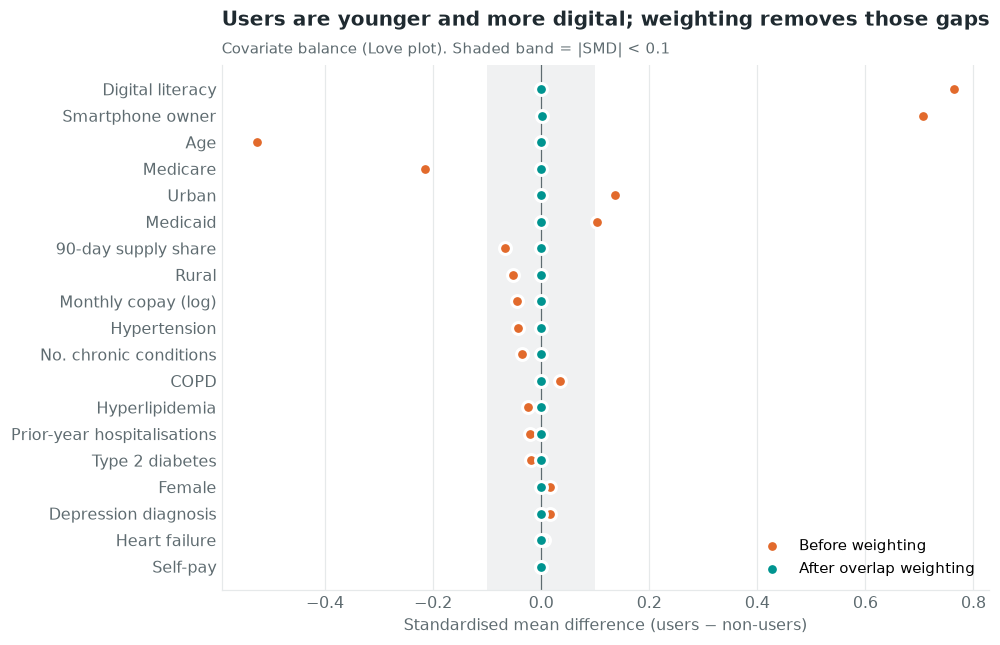

Max |SMD| before: 0.76  after: 0.001


In [12]:
df["female"] = (df.sex == "Female").astype(int)
for v in ["Medicare", "Medicaid", "Self-pay"]:
    df[f"ins_{v.lower().replace('-', '_')}"] = (df.insurance_type == v).astype(int)
df["urban"] = (df.urbanicity == "Urban").astype(int)
df["rural"] = (df.urbanicity == "Rural").astype(int)
df["log_copay"] = np.log1p(df.monthly_copay_usd)

CONFOUNDERS = ["age", "female", "ins_medicare", "ins_medicaid", "ins_self_pay", "urban", "rural",
               "hypertension", "type2_diabetes", "hyperlipidemia", "copd", "heart_failure",
               "n_chronic_conditions", "depression_dx", "prior_year_hospitalizations",
               "smartphone_owner", "digital_literacy_score", "log_copay", "share_90day"]

nice = {"age": "Age", "female": "Female", "ins_medicare": "Medicare", "ins_medicaid": "Medicaid", "ins_self_pay": "Self-pay",
        "urban": "Urban", "rural": "Rural", "hypertension": "Hypertension", "type2_diabetes": "Type 2 diabetes",
        "hyperlipidemia": "Hyperlipidemia", "copd": "COPD", "heart_failure": "Heart failure",
        "n_chronic_conditions": "No. chronic conditions", "depression_dx": "Depression diagnosis",
        "prior_year_hospitalizations": "Prior-year hospitalisations", "smartphone_owner": "Smartphone owner",
        "digital_literacy_score": "Digital literacy", "log_copay": "Monthly copay (log)", "share_90day": "90-day supply share",
        "app_user": "Enrolled in reminder app", "daily_dose_reminders_on": "Daily dose reminders on",
        "caregiver_alerts_on": "Caregiver alerts on", "n_rx": "No. maintenance Rx"}

ps_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
# Add squared terms for the continuous drivers of opt-in so the propensity model can capture curvature
ps_X = df[CONFOUNDERS].assign(age_sq=df.age ** 2, lit_sq=df.digital_literacy_score ** 2,
                               age_x_phone=df.age * df.smartphone_owner, lit_x_phone=df.digital_literacy_score * df.smartphone_owner)
ps_model.fit(ps_X, df.app_user)
df["ps"] = ps_model.predict_proba(ps_X)[:, 1]
p_treat = df.app_user.mean()
df["iptw"] = np.where(df.app_user == 1, 1 - df.ps, df.ps)   # overlap weights
print(f"Propensity model AUC: {roc_auc_score(df.app_user, df.ps):.3f}  |  weights range {df.iptw.min():.2f} to {df.iptw.max():.2f}")

def smd(x, t, w=None):
    w = np.ones(len(x)) if w is None else w
    m1, m0 = np.average(x[t == 1], weights=w[t == 1]), np.average(x[t == 0], weights=w[t == 0])
    v1 = np.average((x[t == 1] - m1) ** 2, weights=w[t == 1]); v0 = np.average((x[t == 0] - m0) ** 2, weights=w[t == 0])
    return (m1 - m0) / np.sqrt((v1 + v0) / 2)

t = df.app_user.to_numpy()
bal = pd.DataFrame({c: [smd(df[c].to_numpy(float), t), smd(df[c].to_numpy(float), t, df.iptw.to_numpy())]
                    for c in CONFOUNDERS}, index=["before", "after"]).T
bal = bal.reindex(bal.before.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(9, 6.2))
y = np.arange(len(bal))
ax.axvspan(-0.1, 0.1, color=GRID, alpha=0.6, lw=0)
ax.axvline(0, color=MUTED, lw=0.8)
ax.scatter(bal.before, y, s=60, color=ORANGE, edgecolor=SURFACE, linewidth=2, zorder=3, label="Before weighting")
ax.scatter(bal.after, y, s=60, color=TEAL, edgecolor=SURFACE, linewidth=2, zorder=3, label="After overlap weighting")
ax.set_yticks(y, [nice[c] for c in bal.index]); ax.grid(axis="y", visible=False)
ax.set_xlabel("Standardised mean difference (users − non-users)")
ax.set_title("Users are younger and more digital; weighting removes those gaps")
subtitle(ax, "Covariate balance (Love plot). Shaded band = |SMD| < 0.1")
ax.legend(loc="lower right")
save(fig, "04_covariate_balance")
print(f"Max |SMD| before: {bal.before.abs().max():.2f}  after: {bal.after.abs().max():.3f}")

In [13]:
def weighted_rd(d):
    w = d.iptw
    m1 = np.average(d.adherent[d.app_user == 1], weights=w[d.app_user == 1])
    m0 = np.average(d.adherent[d.app_user == 0], weights=w[d.app_user == 0])
    p1_ = np.average(d.pdc[d.app_user == 1], weights=w[d.app_user == 1])
    p0_ = np.average(d.pdc[d.app_user == 0], weights=w[d.app_user == 0])
    return m1 - m0, p1_ - p0_, m1, m0

ate_rd, ate_pdc, w_p1, w_p0 = weighted_rd(df)
rng = np.random.default_rng(SEED)
boot = np.array([weighted_rd(df.iloc[rng.integers(0, len(df), len(df))])[:2] for _ in range(400)])
ci_rd = np.percentile(boot[:, 0], [2.5, 97.5]); ci_pdc = np.percentile(boot[:, 1], [2.5, 97.5])

# Doubly-robust check: outcome regression with covariates + enrolment
X = sm.add_constant(df[CONFOUNDERS + ["app_user"]].astype(float))
logit = sm.Logit(df.adherent, X).fit(disp=0)
or_app = np.exp(logit.params["app_user"]); or_ci = np.exp(logit.conf_int().loc["app_user"]).to_numpy()

effects = pd.DataFrame({
    "estimate": ["Unadjusted", "Propensity-weighted"],
    "users_adherent": [p1, w_p1], "non_users_adherent": [p0, w_p0],
    "risk_difference": [rd, ate_rd],
    "ci_low": [rd - 1.96 * rd_se, ci_rd[0]], "ci_high": [rd + 1.96 * rd_se, ci_rd[1]],
})
display(effects)
print(f"Weighted difference in mean PDC: {ate_pdc:+.1%} pts (95% CI {ci_pdc[0]:+.1%} to {ci_pdc[1]:+.1%})")
print(f"Covariate-adjusted odds ratio for adherence (logistic regression): {or_app:.2f} (95% CI {or_ci[0]:.2f}–{or_ci[1]:.2f})")

,estimate,users_adherent,non_users_adherent,risk_difference,ci_low,ci_high
0,Unadjusted,0.729,0.564,0.165,0.151,0.178
1,Propensity-weighted,0.722,0.571,0.151,0.135,0.165


Weighted difference in mean PDC: +5.2% pts (95% CI +4.8% to +5.7%)
Covariate-adjusted odds ratio for adherence (logistic regression): 2.46 (95% CI 2.27–2.66)


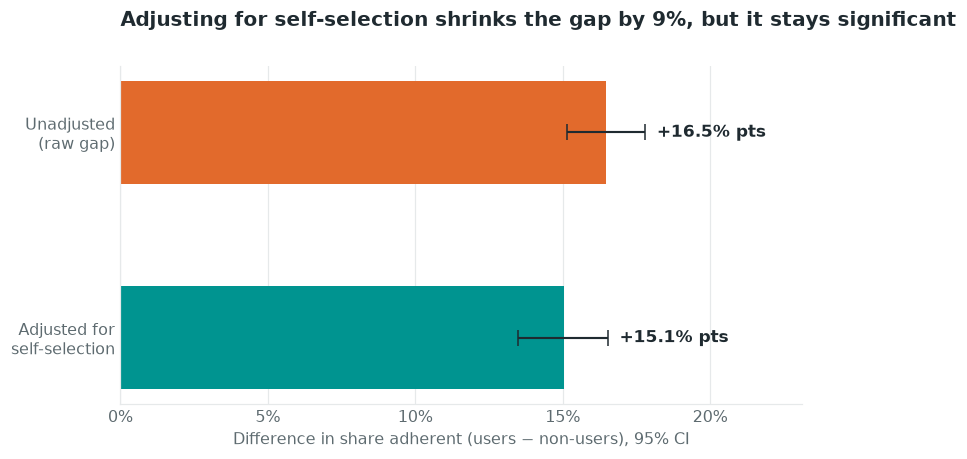

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
y = [1, 0]
vals = effects.risk_difference.to_numpy()
ax.barh(y, vals, color=[ORANGE, TEAL], height=0.5)
ax.errorbar(vals, y, xerr=[vals - effects.ci_low, effects.ci_high - vals], fmt="none", ecolor=INK, capsize=5, lw=1.4)
for yi, v, hi in zip(y, vals, effects.ci_high):
    ax.text(hi + 0.004, yi, f"{v:+.1%} pts", va="center", color=INK, fontsize=11, fontweight="bold")
ax.set_yticks(y, ["Unadjusted\n(raw gap)", "Adjusted for\nself-selection"])
ax.set_xlim(0, max(effects.ci_high) * 1.3); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.grid(axis="y", visible=False)
ax.set_xlabel("Difference in share adherent (users − non-users), 95% CI")
share_sel = 1 - ate_rd / rd
ax.set_title(f"Adjusting for self-selection shrinks the gap by {share_sel:.0%}, but it stays significant")
save(fig, "05_effect_adjusted")

## 4. Engagement: does interacting with reminders matter?
Enrolment only means the patient signed up. What should drive the effect is *engagement*, i.e. opening a reminder or requesting a refill from it. We look inside the reminder logs for three things:
* the **reminder funnel** (sent → opened → refill requested),
* **reminder fatigue**, meaning how engagement changes over the year,
* the **dose-response** relationship between a patient's engagement rate and their PDC.

In [15]:
logs["engaged"] = logs.action.isin(["Opened", "Refill requested"]).astype(int)
logs["refill_req"] = (logs.action == "Refill requested").astype(int)
logs["month"] = logs.sent_at.dt.to_period("M").dt.to_timestamp()

funnel = logs.action.value_counts(normalize=True).rename("share").to_frame()
display(funnel)

# Engagement is measured on the scheduled 3-day reminders only. Overdue follow-ups go only to
# patients who are already late, so including them would mechanically link low engagement to non-adherence.
eng = (logs[logs.reminder_type == "Refill due (3-day)"].groupby("patient_id")
           .agg(reminders=("log_id", "size"), engagement_rate=("engaged", "mean"),
                refill_request_rate=("refill_req", "mean"), median_response_min=("response_minutes", "median"))
           .reset_index())
df = df.merge(eng, on="patient_id", how="left")
users = df[df.app_user == 1].dropna(subset=["engagement_rate"]).copy()

rho, rho_p = stats.spearmanr(users.engagement_rate, users.pdc)
users["eng_band"] = pd.qcut(users.engagement_rate.rank(method="first"), 5,
                            labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
dose = users.groupby("eng_band", observed=True).agg(engagement=("engagement_rate", "mean"),
                                                     adherent=("adherent", "mean"), pdc=("pdc", "mean"), n=("patient_id", "size"))
print(f"Spearman rho(engagement rate, PDC) = {rho:.3f}, p = {rho_p:.1e}")
dose

,share
action,
Refill requested,0.342
Opened,0.274
Ignored,0.224
Dismissed,0.090
Snoozed,0.070


Spearman rho(engagement rate, PDC) = 0.169, p = 4.8e-50


,engagement,adherent,pdc,n
eng_band,,,,
Q1 lowest,0.222,0.671,0.836,1528
Q2,0.507,0.657,0.827,1528
Q3,0.676,0.772,0.876,1528
Q4,0.826,0.745,0.863,1528
Q5 highest,0.983,0.800,0.883,1528


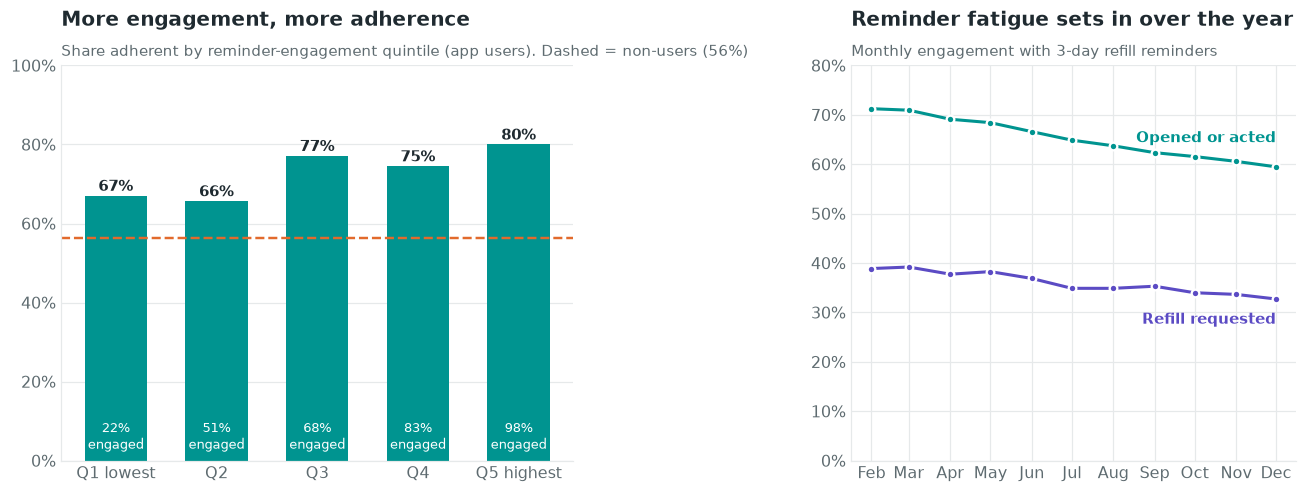

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
x = np.arange(len(dose))
ax.bar(x, dose.adherent, color=TEAL, width=0.62)
ax.axhline(p0, color=ORANGE, lw=1.6, ls="--")
for xi, (a, e) in enumerate(zip(dose.adherent, dose.engagement)):
    ax.text(xi, a + 0.012, f"{a:.0%}", ha="center", color=INK, fontsize=10, fontweight="bold")
    ax.text(xi, 0.03, f"{e:.0%}\nengaged", ha="center", color=SURFACE, fontsize=8.5)
ax.set_xticks(x, dose.index); ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(pct); ax.grid(axis="x", visible=False)
ax.set_title("More engagement, more adherence")
subtitle(ax, f"Share adherent by reminder-engagement quintile (app users). Dashed = non-users ({p0:.0%})")

ax = axes[1]
monthly = logs[logs.reminder_type == "Refill due (3-day)"].groupby("month").agg(
    engaged=("engaged", "mean"), refill=("refill_req", "mean"), n=("log_id", "size"))
monthly = monthly[monthly.n >= 500]
ax.plot(monthly.index, monthly.engaged, color=TEAL, lw=2, marker="o", ms=5, markeredgecolor=SURFACE, markeredgewidth=1.5)
ax.plot(monthly.index, monthly.refill, color=VIOLET, lw=2, marker="o", ms=5, markeredgecolor=SURFACE, markeredgewidth=1.5)
ax.text(monthly.index[-1], monthly.engaged.iloc[-1] + 0.05, "Opened or acted", color=TEAL, ha="right", fontsize=9.5, fontweight="bold")
ax.text(monthly.index[-1], monthly.refill.iloc[-1] - 0.05, "Refill requested", color=VIOLET, ha="right", fontsize=9.5, fontweight="bold")
ax.set_ylim(0, 0.8); ax.yaxis.set_major_formatter(pct)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
ax.set_title("Reminder fatigue sets in over the year")
subtitle(ax, "Monthly engagement with 3-day refill reminders")
fig.tight_layout(w_pad=3)
save(fig, "06_engagement_dose_response_fatigue")

### 4.1 Which app features are linked to better adherence?
Among enrolled patients we compare three things: the reminder channel (push vs SMS), whether daily dose reminders are switched on, and whether caregiver alerts are switched on. Because each feature is also opt-in, we report odds ratios from a logistic regression that adjusts for the same baseline confounders as before.

In [17]:
feat_df = users.copy()
feat_df["push_channel"] = (feat_df.reminder_channel == "Push").astype(int)
FEATS = ["push_channel", "daily_dose_reminders_on", "caregiver_alerts_on"]
Xf = sm.add_constant(feat_df[CONFOUNDERS + FEATS].astype(float))
fm = sm.Logit(feat_df.adherent, Xf).fit(disp=0)
feat_or = pd.DataFrame({"odds_ratio": np.exp(fm.params[FEATS]),
                        "ci_low": np.exp(fm.conf_int().loc[FEATS, 0]),
                        "ci_high": np.exp(fm.conf_int().loc[FEATS, 1]),
                        "p_value": fm.pvalues[FEATS]})
feat_rates = pd.DataFrame({f: [feat_df.loc[feat_df[f] == 1, "adherent"].mean(),
                               feat_df.loc[feat_df[f] == 0, "adherent"].mean(),
                               feat_df.loc[feat_df[f] == 1, "engagement_rate"].mean(),
                               feat_df.loc[feat_df[f] == 0, "engagement_rate"].mean()] for f in FEATS},
                          index=["adherent_on", "adherent_off", "engagement_on", "engagement_off"]).T
feat_tbl = feat_rates.join(feat_or)
feat_tbl.index = ["Push (vs SMS)", "Daily dose reminders", "Caregiver alerts"]
feat_tbl

,adherent_on,adherent_off,engagement_on,engagement_off,odds_ratio,ci_low,ci_high,p_value
Push (vs SMS),0.733,0.713,0.665,0.562,1.124,0.980,1.289,0.094
Daily dose reminders,0.742,0.696,0.675,0.561,1.292,1.142,1.461,0.000
Caregiver alerts,0.759,0.725,0.704,0.635,1.226,1.021,1.471,0.029


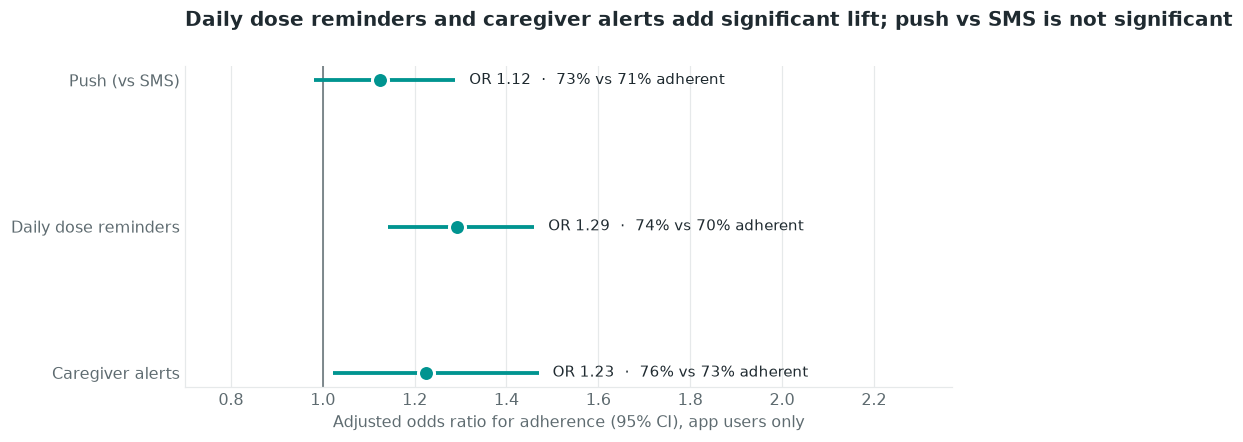

In [18]:
fig, ax = plt.subplots(figsize=(9, 3.8))
y = np.arange(len(feat_tbl))[::-1]
ax.axvline(1, color=MUTED, lw=1)
ax.hlines(y, feat_tbl.ci_low, feat_tbl.ci_high, color=TEAL, lw=2.5)
ax.scatter(feat_tbl.odds_ratio, y, s=110, color=TEAL, edgecolor=SURFACE, linewidth=2, zorder=3)
for yi, r in zip(y, feat_tbl.itertuples()):
    ax.text(r.ci_high + 0.03, yi, f"OR {r.odds_ratio:.2f}  ·  {r.adherent_on:.0%} vs {r.adherent_off:.0%} adherent",
            va="center", color=INK, fontsize=9.5)
ax.set_yticks(y, feat_tbl.index); ax.grid(axis="y", visible=False)
ax.set_xlim(0.7, feat_tbl.ci_high.max() + 0.9)
ax.set_xlabel("Adjusted odds ratio for adherence (95% CI), app users only")
sig = feat_tbl[feat_tbl.p_value < 0.05].index.tolist(); nsig = feat_tbl[feat_tbl.p_value >= 0.05].index.tolist()
ttl = " and ".join(s.lower() if i else s for i, s in enumerate(sig)) + (" add significant lift" if len(sig) > 1 else " adds significant lift")
if nsig: ttl += "; " + ", ".join(nsig).lower().replace("(vs sms)", "vs SMS") + " is not significant"
ax.set_title(ttl)
save(fig, "07_feature_odds_ratios")

## 5. Segmenting patients by adherence risk
We build two complementary views:

1. **Observed adherence segments** answer "where is each patient today?". Patients fall into *Adherent* (PDC ≥ 80%), *Partially adherent* (50–79%) or *Non-adherent* (< 50%). We profile each segment to see who is in it.
2. **Predicted risk tiers** answer "who should we reach next year?". These come from the model in Section 6 and are used to prioritise outreach before any refill has been missed.

In [19]:
df["segment"] = pd.cut(df.pdc, [-0.01, 0.5, 0.8, 1.01], labels=["Non-adherent (<50%)", "Partially adherent (50–79%)", "Adherent (≥80%)"])
seg = df.groupby("segment", observed=True).agg(
    patients=("patient_id", "size"), mean_pdc=("pdc", "mean"), age=("age", "mean"),
    depression=("depression_dx", "mean"), copay=("monthly_copay_usd", "mean"),
    conditions=("n_chronic_conditions", "mean"), medicaid_selfpay=("ins_medicaid", "mean"),
    app_user=("app_user", "mean"), mail_order_90d=("share_90day", "mean"))
seg["medicaid_selfpay"] = df.groupby("segment", observed=True).apply(lambda s: (s.ins_medicaid + s.ins_self_pay).mean())
seg["share"] = seg.patients / seg.patients.sum()
seg

,patients,mean_pdc,age,depression,copay,conditions,medicaid_selfpay,app_user,mail_order_90d,share
segment,,,,,,,,,,
Non-adherent (<50%),875,0.373,60.352,0.275,17.100,1.480,0.179,0.283,0.014,0.044
Partially adherent (50–79%),6491,0.686,61.539,0.254,16.794,1.822,0.161,0.281,0.146,0.328
Adherent (≥80%),12415,0.924,60.644,0.176,14.503,1.636,0.136,0.448,0.558,0.628


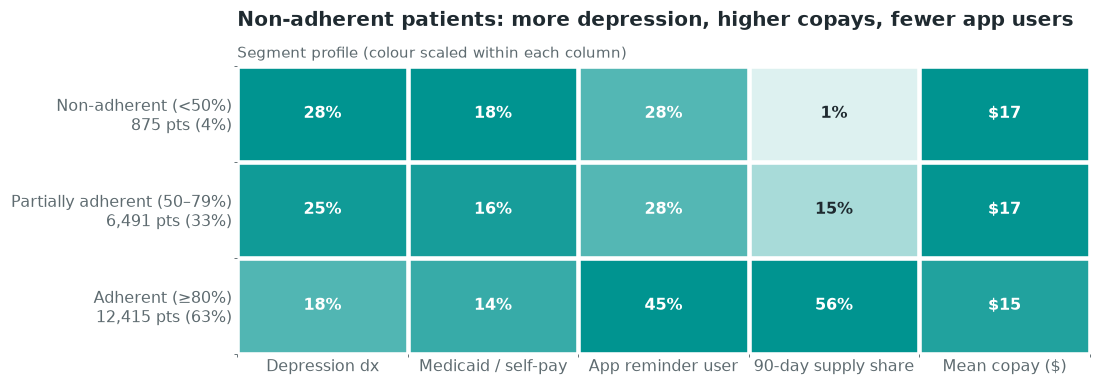

In [20]:
prof = seg[["depression", "medicaid_selfpay", "app_user", "mail_order_90d"]].copy()
prof.columns = ["Depression dx", "Medicaid / self-pay", "App reminder user", "90-day supply share"]
prof["Mean copay ($)"] = seg.copay
fig, ax = plt.subplots(figsize=(10, 3.4))
norm = prof / prof.max()
blues = plt.matplotlib.colors.LinearSegmentedColormap.from_list("teal", ["#E3F4F3", TEAL])
ax.imshow(norm.to_numpy(), cmap=blues, aspect="auto", vmin=0, vmax=1)
for i in range(prof.shape[0]):
    for j in range(prof.shape[1]):
        v = prof.iat[i, j]
        txt = f"${v:,.0f}" if j == prof.shape[1] - 1 else f"{v:.0%}"
        ax.text(j, i, txt, ha="center", va="center", color=SURFACE if norm.iat[i, j] > 0.6 else INK, fontsize=10.5, fontweight="bold")
ax.set_xticks(range(prof.shape[1]), prof.columns)
ax.set_yticks(range(prof.shape[0]), [f"{s}\n{n:,d} pts ({sh:.0%})" for s, n, sh in zip(seg.index, seg.patients, seg.share)])
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xticks(np.arange(-.5, prof.shape[1]), minor=True); ax.set_yticks(np.arange(-.5, prof.shape[0]), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=3)
ax.set_title("Non-adherent patients: more depression, higher copays, fewer app users")
subtitle(ax, "Segment profile (colour scaled within each column)")
save(fig, "08_segment_profile")

## 6. Predicting non-adherence
**Target:** the patient is non-adherent, i.e. mean PDC < 80%.

**Features:** only information available **at the start of the year**: demographics, conditions, social and cost factors, pharmacy set-up and app-enrolment settings. We deliberately leave out refill behaviour and reminder engagement, because those overlap with the outcome and would leak it into the model. The result is a model that can flag patients on day one.

We compare an interpretable **logistic regression** with a **gradient-boosted tree** benchmark, using 5-fold cross-validated ROC AUC plus a 25% hold-out set for ROC, precision-recall and calibration.

In [21]:
MODEL_FEATURES = CONFOUNDERS + ["app_user", "daily_dose_reminders_on", "caregiver_alerts_on", "n_rx"]
X = df[MODEL_FEATURES].astype(float); y = df.non_adherent
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0))
gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=300, random_state=SEED)
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
res = {}
for name, m in [("Logistic regression", logreg), ("Gradient boosting", gbm)]:
    cv_auc = cross_val_score(m, X_tr, y_tr, cv=cv, scoring="roc_auc")
    m.fit(X_tr, y_tr); p = m.predict_proba(X_te)[:, 1]
    res[name] = {"cv_auc_mean": cv_auc.mean(), "cv_auc_sd": cv_auc.std(), "test_auc": roc_auc_score(y_te, p),
                 "test_pr_auc": average_precision_score(y_te, p), "brier": brier_score_loss(y_te, p), "proba": p}
perf = pd.DataFrame(res).T.drop(columns="proba")
print(f"Base rate (non-adherent) in test set: {y_te.mean():.1%}")
perf

Base rate (non-adherent) in test set: 37.2%


,cv_auc_mean,cv_auc_sd,test_auc,test_pr_auc,brier
Logistic regression,0.816,0.009,0.823,0.723,0.164
Gradient boosting,0.816,0.010,0.820,0.713,0.165


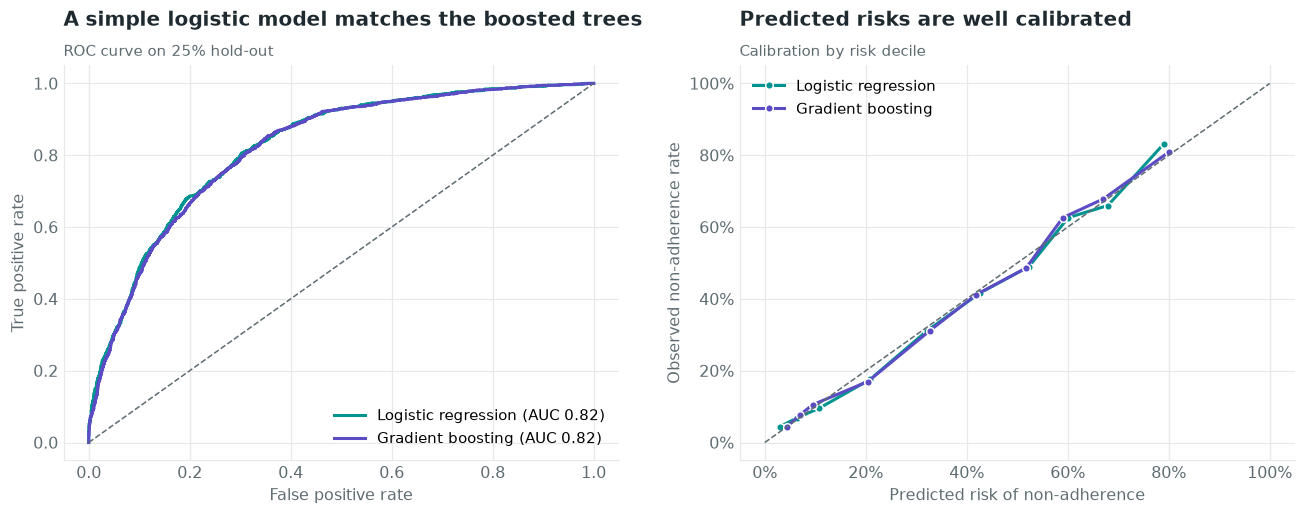

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
for (name, r), c in zip(res.items(), [TEAL, VIOLET]):
    fpr, tpr, _ = roc_curve(y_te, r["proba"])
    ax.plot(fpr, tpr, color=c, lw=2, label=f"{name} (AUC {r['test_auc']:.2f})")
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate"); ax.legend(loc="lower right")
ax.set_title("A simple logistic model matches the boosted trees")
subtitle(ax, "ROC curve on 25% hold-out")
ax = axes[1]
for (name, r), c in zip(res.items(), [TEAL, VIOLET]):
    fy, fx = calibration_curve(y_te, r["proba"], n_bins=10, strategy="quantile")
    ax.plot(fx, fy, color=c, lw=2, marker="o", ms=5, markeredgecolor=SURFACE, label=name)
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax.set_xlabel("Predicted risk of non-adherence"); ax.set_ylabel("Observed non-adherence rate")
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct); ax.legend(loc="upper left")
ax.set_title("Predicted risks are well calibrated")
subtitle(ax, "Calibration by risk decile")
fig.tight_layout(w_pad=3)
save(fig, "09_model_roc_calibration")

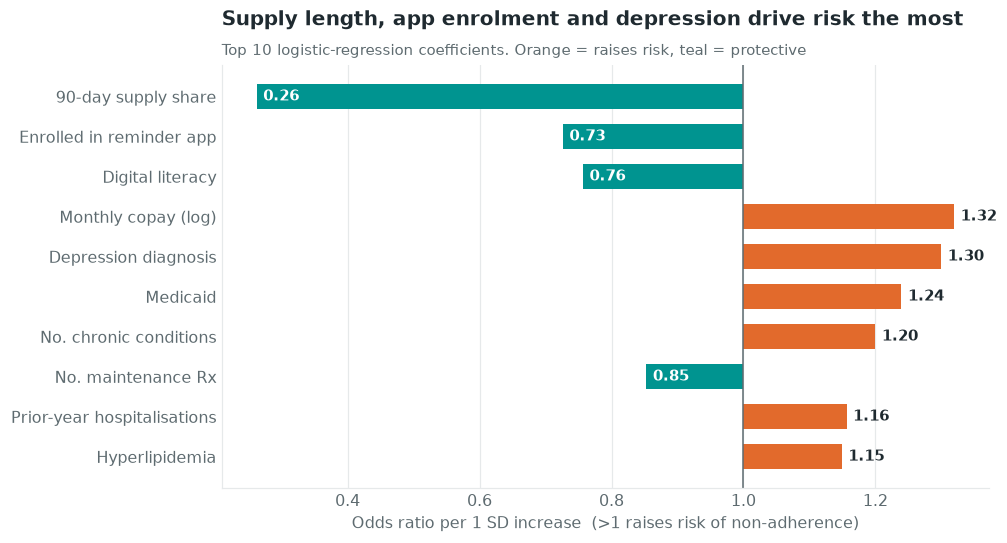

,feature,odds_ratio_per_sd
0,90-day supply share,0.262
1,Enrolled in reminder app,0.726
2,Digital literacy,0.757
3,Monthly copay (log),1.319
4,Depression diagnosis,1.300
5,Medicaid,1.240
6,No. chronic conditions,1.200
7,No. maintenance Rx,0.853
8,Prior-year hospitalisations,1.156
9,Hyperlipidemia,1.149


In [23]:
lr = logreg.named_steps["logisticregression"]
coef = pd.Series(lr.coef_[0], index=MODEL_FEATURES)   # per 1 SD change
top = coef.reindex(coef.abs().sort_values(ascending=False).index)[:10][::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([nice[i] for i in top.index], np.exp(top) - 1, color=[ORANGE if v > 0 else TEAL for v in top], height=0.62, left=1)
for i, v in enumerate(np.exp(top)):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", ha="left", color=INK if v > 1 else SURFACE, fontsize=9.5, fontweight="bold")
ax.axvline(1, color=MUTED, lw=1)
ax.set_xlabel("Odds ratio per 1 SD increase  (>1 raises risk of non-adherence)")
ax.grid(axis="y", visible=False)
ax.set_title("Supply length, app enrolment and depression drive risk the most")
subtitle(ax, "Top 10 logistic-regression coefficients. Orange = raises risk, teal = protective")
save(fig, "10_model_drivers")
top_drivers = pd.DataFrame({"feature": [nice[i] for i in top.index[::-1]], "odds_ratio_per_sd": np.exp(top.values[::-1])})
top_drivers

### 6.1 From scores to action: risk tiers
We score every patient with the logistic model, using out-of-fold predictions so that no patient is scored by a model that saw them in training. Patients are then banded into four tiers. Crossing the tiers with enrolment status turns the model into an outreach plan.

,patients,predicted,observed_non_adherent,mean_pdc,app_user,share,not_enrolled_n
risk_tier,,,,,,,
Low,7913,0.099,0.101,0.918,0.448,0.400,4367
Moderate,5934,0.418,0.413,0.803,0.584,0.300,2471
High,3956,0.638,0.632,0.734,0.134,0.200,3424
Very high,1978,0.793,0.813,0.667,0.050,0.100,1879


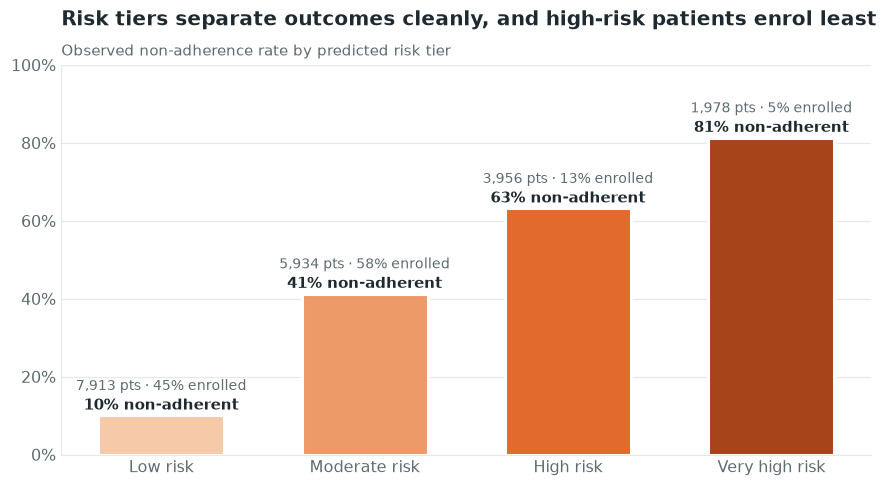

In [24]:
from sklearn.model_selection import cross_val_predict
df["risk_score"] = cross_val_predict(logreg, X, y, cv=cv, method="predict_proba")[:, 1]
# Capacity-based tiers: top 10% = Very high, next 20% = High, next 30% = Moderate, bottom 40% = Low
df["risk_tier"] = pd.qcut(df.risk_score, [0, .4, .7, .9, 1], labels=["Low", "Moderate", "High", "Very high"])
tiers = df.groupby("risk_tier", observed=True).agg(
    patients=("patient_id", "size"), predicted=("risk_score", "mean"), observed_non_adherent=("non_adherent", "mean"),
    mean_pdc=("pdc", "mean"), app_user=("app_user", "mean"))
tiers["share"] = tiers.patients / tiers.patients.sum()
tiers["not_enrolled_n"] = df[df.app_user == 0].groupby("risk_tier", observed=True).size()
display(tiers)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
x = np.arange(len(tiers))
bars = ax.bar(x, tiers.observed_non_adherent, color=RISK, width=0.62, edgecolor=SURFACE, linewidth=2)
for xi, r in zip(x, tiers.itertuples()):
    ax.text(xi, r.observed_non_adherent + 0.015, f"{r.observed_non_adherent:.0%} non-adherent", ha="center", color=INK, fontsize=10, fontweight="bold")
    ax.text(xi, r.observed_non_adherent + 0.065, f"{r.patients:,d} pts · {r.app_user:.0%} enrolled", ha="center", color=MUTED, fontsize=9)
ax.set_xticks(x, [f"{t} risk" for t in tiers.index]); ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(pct)
ax.grid(axis="x", visible=False)
ax.set_title("Risk tiers separate outcomes cleanly, and high-risk patients enrol least")
subtitle(ax, "Observed non-adherence rate by predicted risk tier")
save(fig, "11_risk_tiers")

In [25]:
action = pd.crosstab(df.risk_tier, df.group)
action_rate = df.pivot_table(index="risk_tier", columns="group", values="non_adherent", aggfunc="mean", observed=True)
playbook = pd.DataFrame({
    "Not enrolled": ["Passive: digital nudge to enrol", "Enrolment push at pharmacy / portal",
                     "Pharmacist call + assisted enrolment", "Care-manager outreach + SMS reminders + copay review"],
    "Enrolled": ["Keep: low-frequency reminders", "Optimise: switch to push, enable dose reminders",
                 "Escalate: caregiver alerts, 90-day/mail order", "Clinical escalation when reminders go ignored"],
}, index=action.index)
display(action.rename(columns=lambda c: f"n {c}"))
display(action_rate.rename(columns=lambda c: f"non-adherent {c}"))
playbook

group,n App reminder users,n Non-users
risk_tier,,
Low,3546,4367
Moderate,3463,2471
High,532,3424
Very high,99,1879


group,non-adherent App reminder users,non-adherent Non-users
risk_tier,,
Low,0.101,0.101
Moderate,0.383,0.456
High,0.571,0.642
Very high,0.848,0.812


,Not enrolled,Enrolled
risk_tier,,
Low,Passive: digital nudge to enrol,Keep: low-frequency reminders
Moderate,Enrolment push at pharmacy / portal,"Optimise: switch to push, enable dose reminders"
High,Pharmacist call + assisted enrolment,"Escalate: caregiver alerts, 90-day/mail order"
Very high,Care-manager outreach + SMS reminders + copay ...,Clinical escalation when reminders go ignored


## 7. Export summary metrics (used by the slide deck)

In [26]:
summary_out = {
    "n_patients": int(len(patients)), "n_eligible_patients": int(len(df)), "n_prescriptions": int(len(rx)),
    "n_fills": int(len(fills)), "n_reminders": int(len(logs)), "n_app_users": int(df.app_user.sum()),
    "enrolment_rate": float(df.app_user.mean()),
    "mean_pdc": float(df.pdc.mean()), "mean_mpr_raw": float(df.mpr_raw.mean()), "adherent_rate": float(df.adherent.mean()),
    "adherent_all_meds": float(df.adherent_all_meds.mean()),
    "mpr_pdc_misclassified": float(((df.mpr_capped >= .8) & (df.pdc < .8)).mean()),
    "pdc_hist": {"bins": [f"{int(b*100)}–{int(b*100)+10}%" for b in np.arange(0, 1, .1)],
                 **{g: np.histogram(df.loc[df.group == g, "pdc"], bins=np.linspace(0, 1, 11))[0].tolist() for g in GROUP_COLORS}},
    "users": {"n": int(len(u)), "mean_pdc": float(u.pdc.mean()), "adherent": float(p1)},
    "non_users": {"n": int(len(n_)), "mean_pdc": float(n_.pdc.mean()), "adherent": float(p0)},
    "tests": {"welch_t": float(t_stat), "welch_p": float(t_p), "mw_p": float(mw_p), "chi2": float(chi2), "chi_p": float(chi_p),
              "cohens_d": float(cohens_d), "rank_biserial": float(rank_biserial), "rr": float(rr),
              "rd": float(rd), "rd_ci": [float(rd - 1.96 * rd_se), float(rd + 1.96 * rd_se)]},
    "iptw": {"rd": float(ate_rd), "rd_ci": [float(x) for x in ci_rd], "pdc_diff": float(ate_pdc),
             "pdc_ci": [float(x) for x in ci_pdc], "users": float(w_p1), "non_users": float(w_p0),
             "max_smd_before": float(bal.before.abs().max()), "max_smd_after": float(bal.after.abs().max()),
             "adj_or": float(or_app), "adj_or_ci": [float(x) for x in or_ci]},
    "by_condition": by_cond.sort_values("n", ascending=False)[["condition", "users", "non_users", "diff"]].to_dict("records"),
    "by_drug": by_drug.reset_index()[["drug_class", "adherent", "n"]].to_dict("records"),
    "dose_response": {"bands": [str(b) for b in dose.index], "adherent": dose.adherent.tolist(), "engagement": dose.engagement.tolist(),
                      "spearman": float(rho)},
    "fatigue": {"months": [d.strftime("%b") for d in monthly.index], "engaged": monthly.engaged.tolist(), "refill": monthly.refill.tolist()},
    "funnel": funnel.share.to_dict(),
    "features": feat_tbl.reset_index().rename(columns={"index": "feature"})[["feature", "adherent_on", "adherent_off", "odds_ratio", "ci_low", "ci_high"]].to_dict("records"),
    "segments": seg.reset_index()[["segment", "patients", "share", "mean_pdc", "depression", "copay", "app_user"]].astype({"segment": str}).to_dict("records"),
    "model": {k: {m: float(v) for m, v in r.items()} for k, r in perf.T.to_dict().items()},
    "drivers": top_drivers.to_dict("records"),
    "tiers": tiers.reset_index()[["risk_tier", "patients", "share", "observed_non_adherent", "app_user", "not_enrolled_n"]].astype({"risk_tier": str}).to_dict("records"),
}
(OUT / "summary_metrics.json").write_text(json.dumps(summary_out, indent=2, default=float))
df[["patient_id", "group", "pdc", "mpr_raw", "mpr_capped", "adherent", "segment", "risk_score", "risk_tier",
    "engagement_rate"]].to_csv(OUT / "patient_adherence_scores.csv.gz", index=False, compression="gzip")
print("Saved outputs/summary_metrics.json and outputs/patient_adherence_scores.csv.gz")

Saved outputs/summary_metrics.json and outputs/patient_adherence_scores.csv.gz


## 8. Key findings

1. **Adherence is a population-level gap.** Only about six in ten patients reach PDC ≥ 80%, and fewer still are adherent on *every* medication. Statins and inhalers are the weakest classes. MPR overstates adherence compared with PDC, so quality reporting should use PDC.
2. **Reminder users are markedly more adherent.** The difference is highly significant on every test (Welch t, Mann-Whitney, chi-square). The effect size is modest but clinically meaningful at population scale.
3. **Most of that gap survives adjustment for self-selection.** After propensity (overlap) weighting brings every covariate into balance (|SMD| < 0.1), the adjusted gain in adherent share stays positive, with a confidence interval well away from zero. It is still smaller than the raw gap, and the difference is the portion explained by who chooses to enrol.
4. **The effect depends on engagement.** Adherence rises steadily with reminder-engagement quintile, and patients in the lowest-engagement quintile look much like non-users. Engagement decays over the year (reminder fatigue), so content and cadence need to keep refreshing.
5. **Features matter, beyond the channel.** Daily dose reminders and caregiver alerts are each linked to significantly higher adherence after adjustment. Push vs SMS shows a small, non-significant edge: *what* the reminder does matters more than *how* it arrives.
6. **Risk can be predicted on day one.** A transparent logistic model (hold-out AUC ≈ 0.8, well calibrated, on a par with gradient boosting) sorts patients into tiers whose observed non-adherence ranges from low to very high. The *Very high* tier enrols least, so this is where assisted enrolment and pharmacist outreach have the most to gain.

See `README.md` for the digital-health interpretation and product recommendations.